### **Machine Learning: aplicado a dados imobilísticos do Paquistão**
Equipe: Gabriel Souza Dunkel, Guilherme Henriques Almeida, Luca Torres Villela

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

pd.options.display.max_rows = None
df = pd.read_csv('pakistan_house_prices.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


### **Tipo de cada coluna:**
- unnamed: Categórica e Nominal (um tipo de id)
- property_type: Categórica e Nominal
- price: Numérica e Razão
- location: Categórica e Nominal
- city: Categórica e Nominal
- baths e bedrooms: Numérica e Razão
- purpose: Categórica e Nominal (For sale, for rent)
- Area_in_marla: Numérica e Razão

### **Tratamentos iniciais necessários**
- A função *info()* nos mostrou que não há dados nulos ou faltantes. Por isso não removeremos linhas e não faremos inputação
- Removeremos a coluna "unnamed" pois é um tipo de ID e não vai ajudar na análise ou predicão de dados
- Percebemos então que existem alguns dados onde o valor da area e da quantidade de quartos é 0
- Decidimos remover esses dados, não achamos que valia a pena fazer a análise para "prever" os valores, pois tentar vender um apartamento com a metragem errada pode ser considerado crime.
- 10 linhas onde a "Area_in_Marla" = 0, e 294 linhas onde "bedrooms" = 0
- Finalmente faremos a conversão de Marla para metros quadrados na coluna "Area_in_Marla" para uma melhor compreensão



In [3]:
clean_df = df.copy()
clean_df.drop(columns=['Unnamed: 0'], inplace=True)
clean_df = clean_df[clean_df['Area_in_Marla'] != 0] #remover linhas com area 0  (10 linhas)
clean_df = clean_df[clean_df['bedrooms'] != 0] #remover linhas com quartos 0    (294 linhas)
clean_df['area'] = df['Area_in_Marla'] * 25.292852 #converter de Marla pra metro quadrado
clean_df['area'] = clean_df['area'].round(0).astype(int) #converter valor pra inteiro pq normalmente é assim em anuncios de imóveis 
clean_df.drop(columns=['Area_in_Marla'], inplace=True)

print("Número de linhas removidas na limpeza dos dados:")
print(len(df) - len(clean_df))

print("Número de linhas restantes após limpeza dos dados:")
print(len(clean_df))

clean_df.head(10)

# df_farm_house = clean_df[clean_df['property_type'] == 'Farm House'] 
# df_farm_house.sort_values(by='price', ascending=True).head(10)

# print(len(clean_df[clean_df['bedrooms'] == 0]))
# clean_df.sort_values(by='bedrooms', ascending=True).head(10)

Número de linhas removidas na limpeza dos dados:
304
Número de linhas restantes após limpeza dos dados:
99195


,property_type,price,location,city,baths,purpose,bedrooms,area
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,101
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,142
2,House,16500000,G-15,Islamabad,6,For Sale,5,202
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,1012
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,202
5,Flat,7800000,E-11,Islamabad,2,For Sale,2,157
6,Penthouse,40000000,F-11,Islamabad,5,For Sale,5,506
7,Flat,35000000,Diplomatic Enclave,Islamabad,3,For Sale,3,180
8,Flat,13500000,DHA Defence,Islamabad,5,For Sale,3,253
9,Flat,3600000,E-11,Islamabad,1,For Sale,1,78


### Análise Exploratória dos Dados Geral

#### 1. Preço Médio dos Imóveis:

Preço Médio dos Imóveis:  $10,385,728.98

  Preço médio por tipo de propriedade:


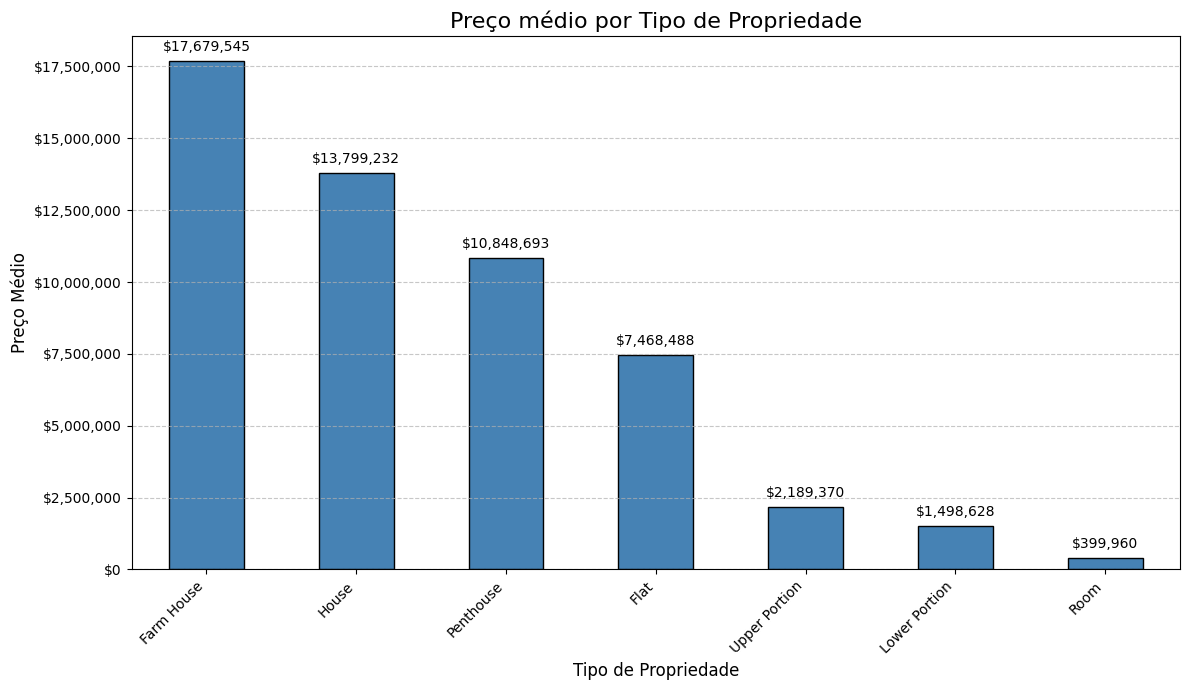

In [4]:
preco_medio = clean_df['price'].mean()
print(f"Preço Médio dos Imóveis:  ${preco_medio:,.2f}\n")

preco_medio_por_tipo = clean_df.groupby('property_type')['price'].mean().sort_values(ascending=False)
    
# Imprime a série formatada para melhor leitura
print("  Preço médio por tipo de propriedade:")
# print(preco_medio_por_tipo.to_string(float_format='{:,.2f}'.format))

plt.figure(figsize=(12, 7))
ax1 = preco_medio_por_tipo.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Preço médio por Tipo de Propriedade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Preço Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

#### 2. Distribuição dos Tipos de Propriedades:

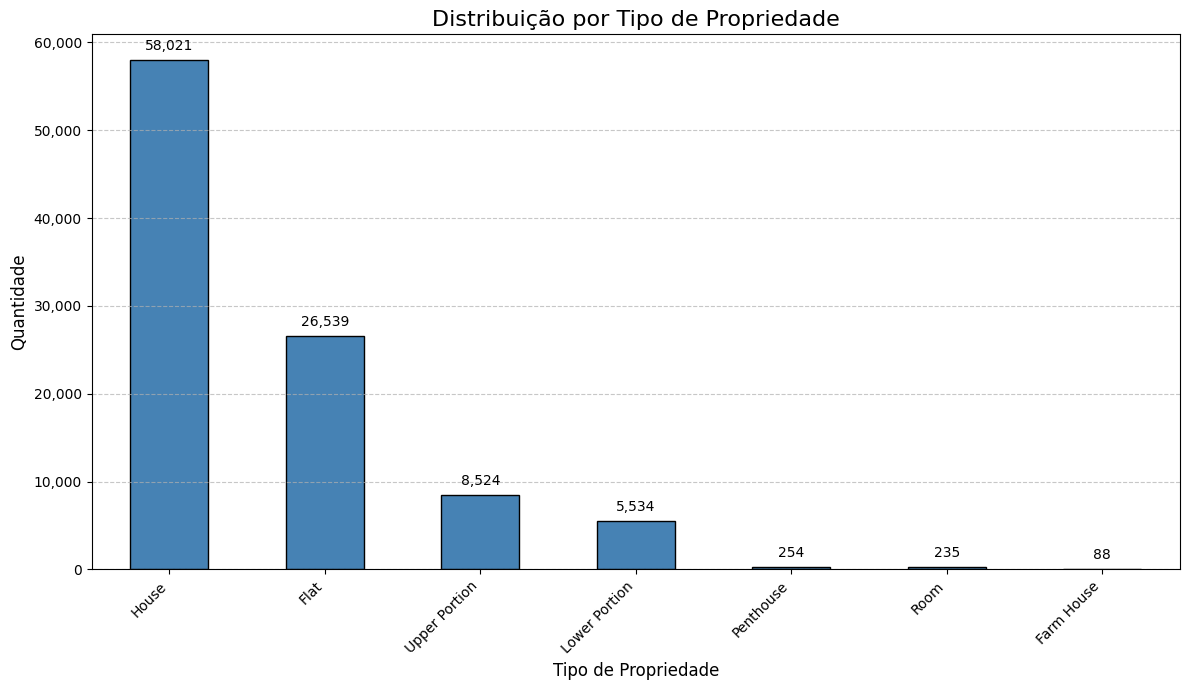

In [5]:

distribuicao_tipo = clean_df['property_type'].value_counts()
# print(distribuicao_tipo)
# print("\n")

plt.figure(figsize=(12, 7))
ax1 = distribuicao_tipo.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribuição por Tipo de Propriedade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

#### 3. Propriedades 'For Sale' por Cidade:

Quantidade total de propriedades 'For Sale':
70734


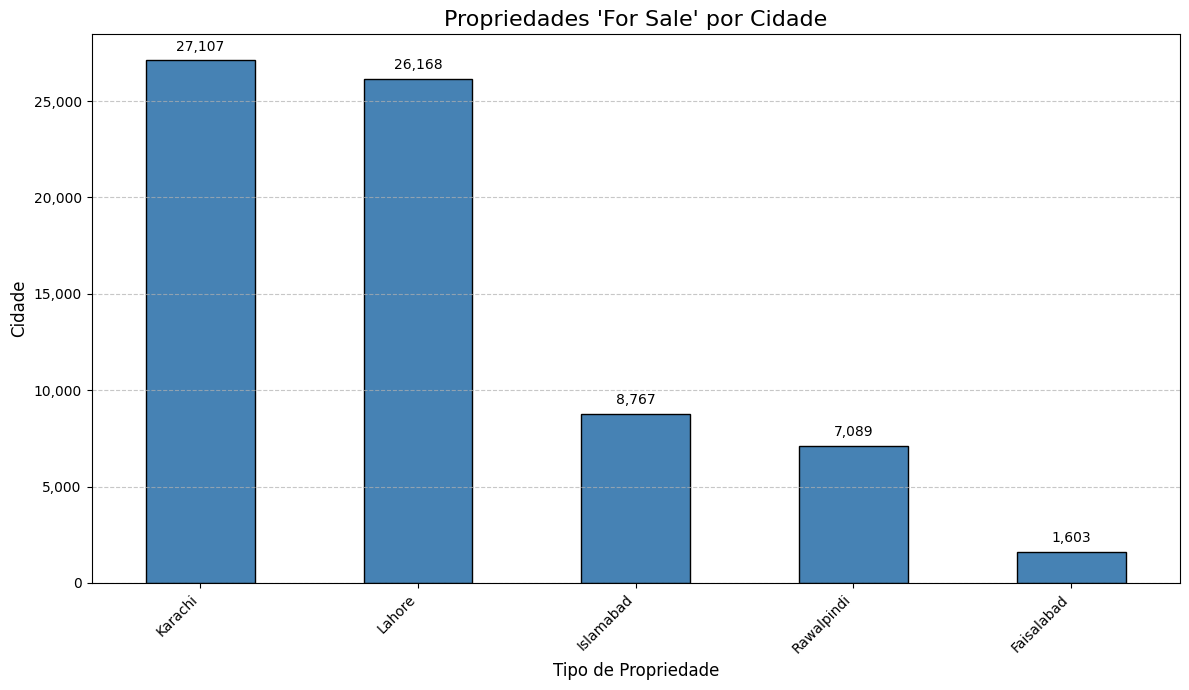

In [6]:
df_em_venda = clean_df[clean_df['purpose'] == 'For Sale']

quantidade_venda = len(df_em_venda)
em_venda_por_cidade = clean_df[clean_df['purpose'] == 'For Sale']['city'].value_counts()

print("Quantidade total de propriedades 'For Sale':")
print(quantidade_venda)

plt.figure(figsize=(12, 7))
ax1 = em_venda_por_cidade.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Propriedades \'For Sale\' por Cidade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Cidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

# print(em_venda_por_cidade)
# print("\n")

#### Características das Propriedades (simples):

#### 4. Média de Quartos e Banheiros:

In [7]:
media_comodos = clean_df[['bedrooms', 'baths']].mean().round(2)
# mediana_comodos = clean_df[['bedrooms', 'baths']].median()

print(media_comodos)
print("\n")
# print(mediana_comodos)
# print("\n")

bedrooms    3.36
baths       3.53
dtype: float64




#### 5. Variação do Tamanho (area) por Tipo e Localização:


In [8]:
%matplotlib inline
sns.set_theme(style="whitegrid")

# A melhor forma de ver "como varia" é com agregações e gráficos.

# 1: Média de área por TIPO de propriedade
print("  Média de área por tipo de propriedade:")
media_area_por_tipo = clean_df.groupby('property_type')['area'].mean().sort_values(ascending=False)
print(media_area_por_tipo)
print("\n")

# 2: Média de área por CIDADE
# (Usar 'city' é geralmente melhor que 'location', que pode ter valores demais)
print("  Média de área por cidade:")
media_area_por_cidade = clean_df.groupby('city')['area'].mean().sort_values(ascending=False)
print(media_area_por_cidade.all)
print("\n")



  Média de área por tipo de propriedade:
property_type
Farm House       2064.840909
Upper Portion     312.621539
Lower Portion     288.786592
Penthouse         269.641732
House             231.005722
Room              227.936170
Flat              151.283809
Name: area, dtype: float64


  Média de área por cidade:
<bound method Series.all of city
Islamabad     282.800866
Lahore        216.162909
Rawalpindi    206.147604
Karachi       196.433284
Faisalabad    175.837314
Name: area, dtype: float64>




### Análise Exploratória dos Dados Avançada (EDA)